## **QUANTUM SPLIT OPERATOR FOURIER TRANSFORM METHOD**

contoh pada sistem DNA Tautomerization

In [1]:
!pip install qiskit --quiet
!pip install qiskit_ibm_runtime --quiet

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit import *
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Batch

In [2]:
#1D PES for A-T tautomerization
d = 6       #number of points#number of qubit
mass = 1    #mass of the particle
xMin = -5
xMax = -xMin
x = np.linspace(xMin, xMax, num=2**d) #position grid
VV = (0.429*x - 1.126*x**2 - 0.143*x**3 + 0.563*x**4) * 0.1

In [3]:
#inisialisasi gaussian wavepacket on a grid
mu = 1
alpha = 1
psi = (alpha/np.pi)**0.25 * np.exp(-alpha *(x-mu)**2 * 0.5)
psi/= np.sqrt(np.sum(np.abs(psi)**2))   #normalisasi

In [4]:
#preparation of potensial and kinetic split propagation
dx = (xMax-xMin)/(2**d-1)

#KE opertaor
dp = 2*np.pi/(xMax-xMin)
N = 2**d
p= np.zeros(N, dtype=float)

for i in range(N):
    p[i] = dp * (i-N/2)

p = np.fft.fftshift(p)
time_step = 0.01

VVd_prop = np.diag(np.exp(-1j*VV*time_step))    #potential propagator
KED_prop = np.diag(np.exp(-1j*p**2/2/mass*time_step))  #kinetic propagator

In [5]:
#quanutm SOFT circuit preparation
from qiskit.circuit.library import QFT

#inisialisasi circuit kosong
nqubits = d
q_reg = QuantumRegister(nqubits)
c_reg = ClassicalRegister(nqubits)
qc = QuantumCircuit(q_reg, c_reg)

qc.initialize(psi, q_reg[:])

for k in range(600):
    bound_op = Operator(VVd_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=True), q_reg)
    bound_op = Operator(KED_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)

/tmp/ipykernel_163304/3775776292.py:15: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d, do_swaps=True, inverse=True), q_reg)
/tmp/ipykernel_163304/3775776292.py:18: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)


In [6]:
#quantum soft circuit execution
from qiskit import transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator(method='statevector')
qc.save_statevector()

qc_transpiled = transpile(qc, simulator)
psin = simulator.run(qc_transpiled).result().get_statevector()
print(psin)

Statevector([-1.23960251e-05-9.52542071e-06j,
              7.19337966e-07-3.17853239e-05j,
              7.74050567e-06-5.61559498e-05j,
              5.17036285e-05-1.33095131e-04j,
              1.31299586e-04-2.74043879e-04j,
              2.65902436e-04-5.25206996e-04j,
              4.70919395e-04-9.53341891e-04j,
              7.63741598e-04-1.63275419e-03j,
              1.11707064e-03-2.64422812e-03j,
              1.55352895e-03-4.17728233e-03j,
              2.15554110e-03-6.61473499e-03j,
              3.13286849e-03-1.04883686e-02j,
              4.81271477e-03-1.65800107e-02j,
              7.65621274e-03-2.57436904e-02j,
              1.21338888e-02-3.87679844e-02j,
              1.85908350e-02-5.61347184e-02j,
              2.70546167e-02-7.77723999e-02j,
              3.72735471e-02-1.03040713e-01j,
              4.88485114e-02-1.30695198e-01j,
              6.14129811e-02-1.59003362e-01j,
              7.48142408e-02-1.85988859e-01j,
              8.90250497e-02-2.096

In [7]:
#classical soft benchmark
def soft(fxy, emat, Pxy):
    #soft propagation
    out = emat*fxy
    fp = np.fft.fft(out)*Pxy
    out = np.fft.ifft(fp)
    return out

psi_c_init = psi
psi_c = psi_c_init
iteratons = 600

for i in range(iteratons):
    psi_c = soft(psi_c, np.diag(VVd_prop), np.diag(KED_prop))

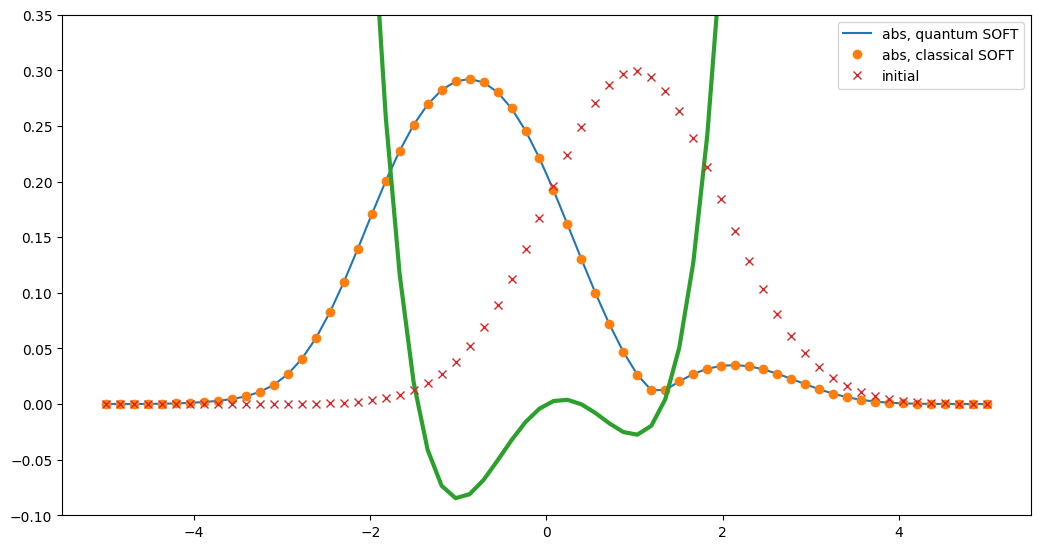

In [8]:
#plotting initial and final wavefunction
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [12.50, 6.50]
#plt.plot(x, np.real(psin), label = 'real')
#plt.plot(x, np.imag(psin), label = 'imag')
plt.plot(x, np.abs(psin), label='abs, quantum SOFT')
plt.plot(x, np.abs(psi_c), 'o', label='abs, classical SOFT')
plt.plot(x, VV, linewidth=3)
plt.plot(x, abs(psi), 'x', label='initial')
leg = plt.legend(loc='upper right')
plt.ylim(-0.1, 0.35)
plt.show()